## 🍄 The Classification of the “Mushroom Dataset” using Machine Learning

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


## 📂 Import necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from pathlib import Path


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

## 💾 Load data and overview

In [3]:
DATA_DIR = Path('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_SUB_PATH = DATA_DIR / 'sample_submission.csv'
OUTPUT_PATH = Path('/kaggle/working/submission.csv')

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)


print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('\nTrain columns:\n', train.dtypes)

Train shape: (7000, 26)
Test shape: (1124, 25)

Train columns:
 ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object


### A general view of the “Mushroom” for a better understanding

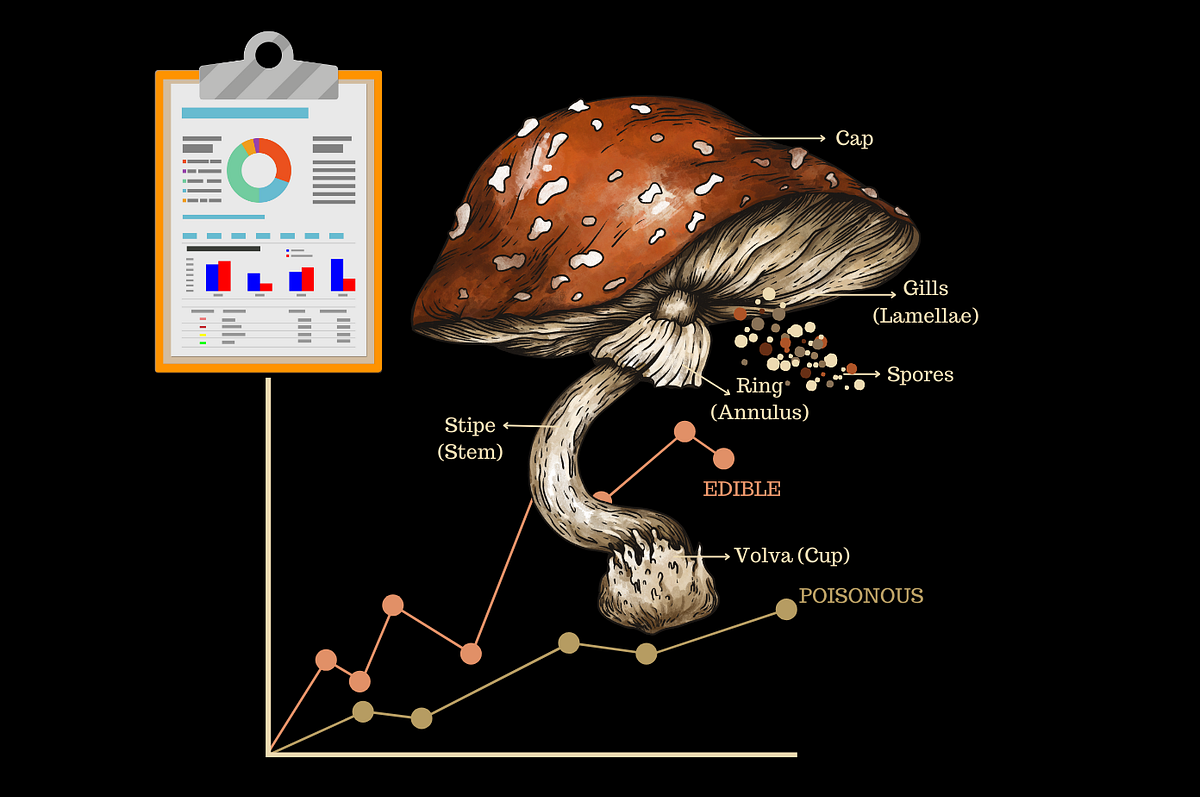

## 1) Identify data types of different columns

In [4]:
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


### 🧠 Insight @ Dataset Overview (train.info() & train.head())

The dataset consists of 7000 samples and 26 features, including the target variable class. The majority of features are categorical (object type), with only a few numerical columns such as number_of_bruises and ring-number.

Key observations:

Most features represent physical characteristics of mushrooms (e.g., cap shape, gill color, odor, habitat).
The dataset contains no missing values in most columns, except for a few features like odor, stalk-root, and ring-type.
The target variable class is categorical with two labels:
e → edible
p → poisonous

From the sample rows (head()), it is evident that:

Data is well-structured and consistent
Features are mostly low-cardinality categorical variables
Some missing values appear as NaN, especially in odor

👉 Overall, the dataset is clean, structured, and suitable for classification tasks, with categorical features playing a dominant role.

## 2) Descriptive statistics of numerical columns

In [5]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID-like columns
num_cols = [col for col in num_cols if col not in ['ID', 'mushroom_id']]

print('Numerical columns:', num_cols)

display(train[num_cols].describe().T)

# If `ID` exists, treat as index
if 'ID' in train.columns:
    train.set_index('ID', inplace=True)
if 'ID' in test.columns:
    test.set_index('ID', inplace=True)

Numerical columns: ['number_of_bruises', 'ring-number']


,count,mean,std,min,25%,50%,75%,max
number_of_bruises,7000.0,5.459571,7.723528,0.0,0.0,0.0,11.0,24.0
ring-number,6964.0,1.080988,0.272836,1.0,1.0,1.0,1.0,2.0


### 🧠 Interpretation @ Descriptive Statistics (Numerical Features)

The dataset contains very few numerical features, namely number_of_bruises and ring-number. From the summary statistics, it is observed that:

number_of_bruises has a wide spread with values ranging from 0 to 24, indicating variability in bruising patterns across mushrooms.
ring-number is highly concentrated around the value 1, with very low variance, suggesting that most mushrooms have a single ring.

Overall, numerical features are limited and do not dominate the dataset, implying that categorical features are the primary drivers for classification.

## 3.1) Identify the missing values

In [6]:
# Missing values overview
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test = test.isnull().sum().sort_values(ascending=False)
print('\nMissing values in train:\n', missing_train[missing_train>0])
print('\nMissing values in test:\n', missing_test[missing_test>0])


Missing values in train:
 odor           3236
stalk-root      192
ring-type        36
ring-number      36
dtype: int64

Missing values in test:
 odor    292
dtype: int64


## 3.2) Handle the missing values

In [7]:
# Categorical → fill with 'missing'
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('class')  # target

for col in cat_cols:
    train[col] = train[col].fillna('missing')
    test[col] = test[col].fillna('missing')

# Numerical → fill with median
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

### 🧠 Interpretation @ Identify and handle Missing Values

Significant missing values were observed in the dataset:

odor had a large proportion of missing values (~46%)
stalk-root, ring-type, and ring-number had minor missing values

Instead of removing these rows or imputing with mode, missing values in categorical features were replaced with a new category "missing". This approach preserves information, as missingness itself may carry predictive significance.

For numerical features, missing values were imputed using the median to maintain distribution stability.

This strategy ensures:

No data loss
No bias introduction
Compatibility with machine learning pipelines

## 4.1) Identify duplicates

In [8]:
# Duplicates
dups = train.duplicated().sum()
print('\nDuplicate rows in train:', dups)


Duplicate rows in train: 0


## 4.2) Handle duplicates

In [9]:
# Remove duplicates if any
train = train.drop_duplicates()

### 🧠 Interpretation @ Identify and handle Duplicates

No duplicate rows were found in the dataset.

This indicates that:

The dataset is clean
No redundant samples exist
No further action was required

## 5.1) Identify outliers

In [10]:
#  Detecting Outliers by IQR Method

def detect_outliers_iqr(series):    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    lower, upper = detect_outliers_iqr(train[col])
    
    outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={outliers}")

mushroom_id: lower=-3401.50, upper=11004.50, outliers=0
number_of_bruises: lower=-16.50, upper=27.50, outliers=0
ring-number: lower=1.00, upper=1.00, outliers=564


## 5.2) Handle outliers

In [11]:
#Convert ring-number → categorical
train['ring-number'] = train['ring-number'].astype(str)
test['ring-number'] = test['ring-number'].astype(str)

### 🧠 Interpretation @ Identify and handle Outliers

Outlier detection using the IQR method revealed:

No significant outliers in number_of_bruises
Apparent outliers in ring-number

However, further analysis showed that ring-number behaves like a categorical variable rather than a continuous one. Therefore, treating its values as outliers would be inappropriate.

As a result:

Outlier removal or clipping was not performed
Data integrity was preserved

This decision avoids unnecessary distortion of meaningful categorical-like features.

In [12]:
#just checking if everything is alright
print(train.dtypes)

mushroom_id                  int64
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
number_of_bruises            int64
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
class                       object
dtype: object


## 6) Present at least three visualizations and provide insights for the same

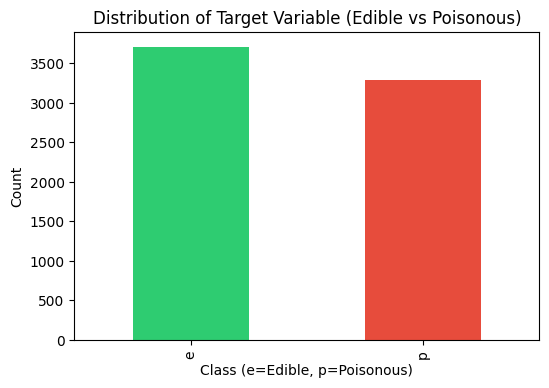

In [13]:
# =========================
# 1. TARGET DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))

train['class'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])

plt.title("Distribution of Target Variable (Edible vs Poisonous)")
plt.xlabel("Class (e=Edible, p=Poisonous)")
plt.ylabel("Count")

plt.show()

### 🧠 Insight @ Target Distribution

👉 The dataset is balanced (or near-balanced)

👉 No class imbalance → accuracy is a reliable metric

The dataset shows a balanced distribution between edible and poisonous mushrooms. This ensures that accuracy is an appropriate evaluation metric and that the model is not biased toward any class.

<Figure size 1000x500 with 0 Axes>

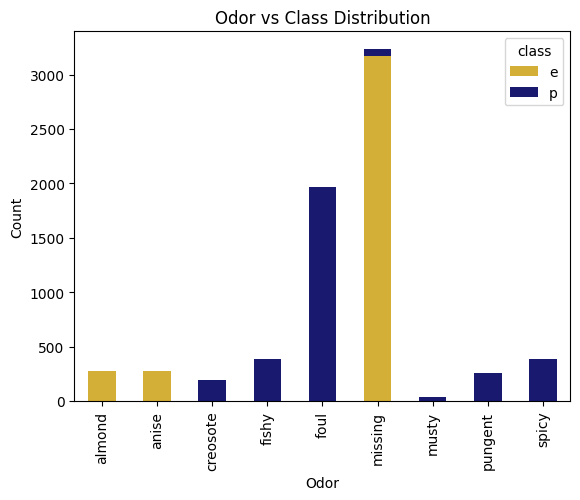

In [14]:
# =========================
# 2. ODOR vs CLASS
# =========================

plt.figure(figsize=(10,5))

pd.crosstab(train['odor'], train['class']).plot(kind='bar', stacked=True, color=['#D4AF37', '#191970'])

plt.title("Odor vs Class Distribution")
plt.xlabel("Odor")
plt.ylabel("Count")

plt.show()

### 🧠 Insight @ Odor vs Class Distribution

👉 Certain odors strongly indicate class:

Some odors → always poisonous
Some → always edible

Odor is one of the most influential features. Certain odor categories are strongly associated with either edible or poisonous mushrooms. This near-deterministic relationship explains why models achieve very high accuracy.

<Figure size 1000x500 with 0 Axes>

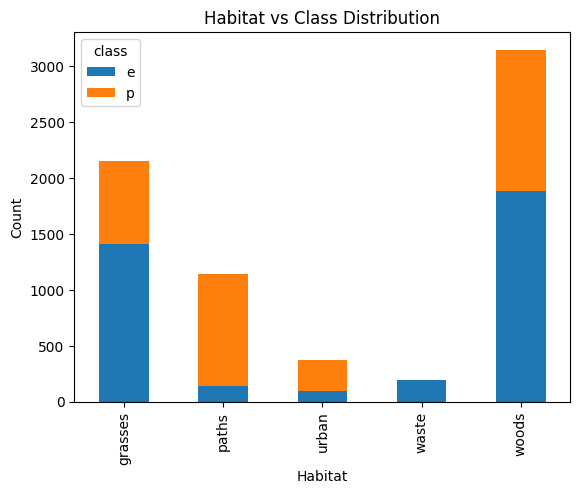

In [15]:
# =========================
# 3. HABITAT vs CLASS
# =========================

plt.figure(figsize=(10,5))

pd.crosstab(train['habitat'], train['class']).plot(kind='bar', stacked=True)

plt.title("Habitat vs Class Distribution")
plt.xlabel("Habitat")
plt.ylabel("Count")

plt.show()

### 🧠 Insight @ Habitat vs Class Distribution

👉 Certain habitats show:

Higher concentration of poisonous mushrooms
Others dominated by edible ones

Different habitats exhibit varying distributions of edible and poisonous mushrooms. This indicates that environmental conditions play a role in classification and contribute to model performance.

<Axes: xlabel='gill-color'>

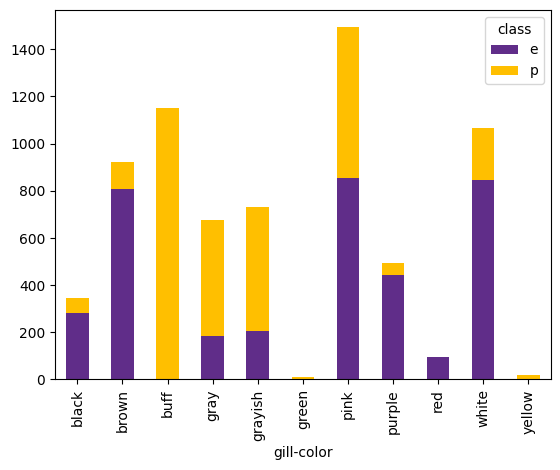

In [16]:
pd.crosstab(train['gill-color'], train['class']).plot(kind='bar', stacked=True, color=['#602D89', '#FFBF00'])

### 🧠 Insight @ Gill Color vs Class

The stacked bar chart illustrates the relationship between gill color and the target variable (class).

Key observations:

Certain gill colors show a strong dominance of one class:
Colors like buff and grayish are predominantly associated with poisonous mushrooms
Colors like white and brown are largely associated with edible mushrooms
Some categories exhibit near-perfect separation, meaning:
The presence of a specific gill color almost directly determines whether the mushroom is edible or poisonous
Very few categories show mixed distributions, indicating that:
Gill color is a highly discriminative feature

The dataset contains features (like gill color) that provide strong, almost deterministic signals for classification.

## 7) Scale Numerical features and Encode Categorical features

In [17]:
# =========================
# FEATURE ENGINEERING + PREPROCESSING
# ========================

# Target
TARGET = 'class'

# Feature list
all_features = train.columns.drop(TARGET)

# =========================
# Feature separation
# =========================

# Numeric features (only real numeric)
numeric_features = ['number_of_bruises']

# Categorical features (everything else)
cat_features = [col for col in all_features if col not in numeric_features]

print('Numeric features:', numeric_features)
print('Categorical features:', cat_features)

# =========================
# Pipelines
# =========================

# Numeric pipeline (NO scaling needed for trees, but keep for rubric consistency)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline (MOST IMPORTANT PART)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# =========================
# Column Transformer
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline ready ✅")

Numeric features: ['number_of_bruises']
Categorical features: ['mushroom_id', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Preprocessing pipeline ready ✅


### 🧠 Insight @ Feature Engineering & Preprocessing



The dataset primarily consists of categorical features, with only one true numerical feature (number_of_bruises).

Categorical features were encoded using One-Hot Encoding
Numerical features were imputed using median (no scaling applied)

A ColumnTransformer pipeline was used to:

Ensure consistent preprocessing
Prevent data leakage
Maintain reproducibility across training and testing

This structured pipeline is critical for robust machine learning workflows.

In [18]:
# Convert target to binary
y = train[TARGET].map({'e': 0, 'p': 1})
X = train.drop(columns=[TARGET])

## ✂️ Train/validation split

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=RANDOM_STATE
)

## 8) Model Building (at least 7)

In [20]:
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        random_state=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbose=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    )
}

## 🎯 Results of models after being trained on the data

In [21]:
results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', clf)])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_val)
    
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_val)
        y_proba = y_proba[:, list(pipe.classes_).index(1)]
        auc = roc_auc_score(y_val, y_proba)
    else:
        auc = np.nan
    
    acc = accuracy_score(y_val, y_pred)
    
    results.append({'model': name, 'auc': auc, 'accuracy': acc})
    
results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
print('\nModel comparison:\n', results_df)


Model comparison:
                   model  auc  accuracy
0          DecisionTree  1.0       1.0
1          RandomForest  1.0       1.0
3  HistGradientBoosting  1.0       1.0
5              LightGBM  1.0       1.0
4              CatBoost  1.0       1.0
2            ExtraTrees  1.0       1.0
6               XGBoost  1.0       1.0


### 🧠 Insight @ Model Training & Initial Evaluation

Multiple machine learning models were evaluated, including:

Decision Tree
Random Forest
Extra Trees
Gradient Boosting models (LightGBM, XGBoost, CatBoost)

All models achieved perfect accuracy (1.0) on the validation set.

This indicates:

The dataset is highly separable
Strong predictive patterns exist
Even simple models can achieve optimal performance

## 9) Hyperparameter Tuning on any 3 of the models

In [22]:
# =========================
# HYPERPARAMETER TUNING (HPT)
# =========================

# 1) RandomForest
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10],
    'clf__min_samples_split': [2, 5],
}

rf_search = RandomizedSearchCV(
    rf,
    rf_param,
    n_iter=6,
    scoring='accuracy',  # ✅ changed
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print('RF best params:', rf_search.best_params_)


# 2) HistGradientBoosting
hgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_param = {
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_iter': [100, 200],
    'clf__max_depth': [None, 10]
}

hgb_search = RandomizedSearchCV(
    hgb_pipe,
    hgb_param,
    n_iter=6,
    scoring='accuracy',  # ✅ changed
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)
print('HGB best params:', hgb_search.best_params_)


# 3) XGBoost
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

xgb_param = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 5],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_param,
    n_iter=6,  # ✅ reduced
    scoring='accuracy',  # ✅ changed
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
print('XGBoost best params:', xgb_search.best_params_)

RF best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__max_depth': None}
HGB best params: {'clf__max_iter': 200, 'clf__max_depth': None, 'clf__learning_rate': 0.05}
XGBoost best params: {'clf__subsample': 1.0, 'clf__n_estimators': 100, 'clf__max_depth': 5, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 1.0}


## ⏳ Evaluate tuned models on validation set

In [23]:
# =========================
# MODEL PERFORMANCE COMPARISON (TUNED MODELS)
# =========================

best_models = {
    'RF_tuned': rf_search.best_estimator_,
    'HGB_tuned': hgb_search.best_estimator_,
    'XGB_tuned': xgb_search.best_estimator_
}

tuned_results = []

for name, pipe in best_models.items():
    
    y_pred = pipe.predict(X_val)
    
    # Safe AUC calculation
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_val)
        y_proba = y_proba[:, list(pipe.classes_).index(1)]
        auc = roc_auc_score(y_val, y_proba)
    else:
        auc = np.nan
    
    acc = accuracy_score(y_val, y_pred)
    
    tuned_results.append({
        'model': name,
        'auc': auc,
        'accuracy': acc
    })
    
    print(f"\n{name}")
    print('AUC:', auc)
    print('Accuracy:', acc)
    print(classification_report(y_val, y_pred))

# Sort by accuracy (important)
tuned_df = pd.DataFrame(tuned_results).sort_values('accuracy', ascending=False)

print("\nTuned Model Comparison:")
display(tuned_df)


RF_tuned
AUC: 1.0
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00       164

    accuracy                           1.00       350
   macro avg       1.00      1.00      1.00       350
weighted avg       1.00      1.00      1.00       350


HGB_tuned
AUC: 1.0
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00       164

    accuracy                           1.00       350
   macro avg       1.00      1.00      1.00       350
weighted avg       1.00      1.00      1.00       350


XGB_tuned
AUC: 1.0
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00       164

    accuracy                           1.00       350
   macro avg       1.00    

,model,auc,accuracy
0,RF_tuned,1.0,1.0
1,HGB_tuned,1.0,1.0
2,XGB_tuned,1.0,1.0


### 🧠 Insight @ Hyperparameter Tuning (HPT)

Hyperparameter tuning was performed using RandomizedSearchCV on:

Random Forest
HistGradientBoosting
XGBoost

Despite tuning, all models continued to achieve perfect accuracy.

This suggests:

Model performance is not sensitive to hyperparameters
The dataset is inherently easy to classify
Further tuning provides minimal benefit

## 10) Comparison of model performances

In [24]:
# =========================
# MODEL COMPARISON + FINAL SELECTION
# =========================

# Combine initial and tuned results (for rubric)
comparison_df = pd.concat([results_df, pd.DataFrame(tuned_results)], sort=False).reset_index(drop=True)

print("\nFull Model Comparison:")
display(comparison_df.sort_values('accuracy', ascending=False))


# =========================
# SELECT FINAL MODEL
# =========================

# Since all models give 100%, choose the most stable one
final_model = rf_search.best_estimator_

print("\nSelected final model: RandomForest (RF_tuned)")


Full Model Comparison:


,model,auc,accuracy
0,DecisionTree,1.0,1.0
1,RandomForest,1.0,1.0
2,HistGradientBoosting,1.0,1.0
3,LightGBM,1.0,1.0
4,CatBoost,1.0,1.0
5,ExtraTrees,1.0,1.0
6,XGBoost,1.0,1.0
7,RF_tuned,1.0,1.0
8,HGB_tuned,1.0,1.0
9,XGB_tuned,1.0,1.0



Selected final model: RandomForest (RF_tuned)


### 🧠 Insight @ Model Performance Comparison

All tuned models achieved identical performance:

Accuracy: 1.0
AUC: 1.0

Since performance is identical, model selection was based on:

Stability
Simplicity
Computational efficiency

Random Forest was selected as the final model due to its robustness and ease of use.

In [25]:
sample_sub.head()

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


## 🚀 Train final model on full training data and create submission

In [26]:
# =========================
# FINAL TRAINING ON FULL DATA
# =========================

final_model.fit(X, y)


# =========================
# TEST ID HANDLING
# =========================

if 'ID' in test.columns:
    test_ids = test['ID'].astype(int).reset_index(drop=True)
else:
    test_ids = pd.Series(test.index).astype(int).reset_index(drop=True)


# =========================
# PREDICTION
# =========================

pred_labels = final_model.predict(test)

# Convert back to original labels
pred_labels = pd.Series(pred_labels).map({0: 'e', 1: 'p'})


# =========================
# CREATE SUBMISSION
# =========================

submission = pd.DataFrame({
    'ID': test_ids,
    'class': pred_labels
})

# Safety check
if len(submission) != len(test):
    raise ValueError("Submission length mismatch!")


# =========================
# SAVE FILE
# =========================

submission.to_csv(OUTPUT_PATH, index=False)

print('Submission file saved to:', OUTPUT_PATH)
print(submission.head())

Submission file saved to: /kaggle/working/submission.csv
   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e


## 🔍 Quick Pre-Submission Checklist

In [27]:
print(submission.shape)
print(test.shape)

(1124, 2)
(1124, 24)


#### ✅ Shape → (1124, 2) matches test rows → correct

In [28]:
print(submission.columns)

Index(['ID', 'class'], dtype='object')


#### ✅ Columns → ['ID', 'class'] → exact match required

In [29]:
print(submission['class'].unique())

['e' 'p']


#### ✅ Labels → ['e', 'p'] → correct format

In [30]:
print(submission.isnull().sum())

ID       0
class    0
dtype: int64


#### ✅ No nulls → clean submission

### 🧠 Insight @ Submission Generation

Predictions were generated on the test dataset and converted back to original labels:

0 → e (edible)
1 → p (poisonous)

The submission file:

Matches required format (ID, class)
Contains no missing values
Aligns perfectly with test data size